# Series
#### A one-dimensional labeled array

In [1]:
import numpy as np 
import pandas as pd 

#### From ndarray

In [2]:
# The passed index is a list of axis labels 
s = pd.Series(np.random.randn(5), index = ["a", "b", "c", "d", "e"])
s

a   -1.352126
b    1.465048
c   -0.040581
d   -0.329514
e   -0.852854
dtype: float64

In [3]:
s.index

Index(['a', 'b', 'c', 'd', 'e'], dtype='object')

In [4]:
# If no index is provided, one will be created:
pd.Series(np.random.randn(5))

0   -0.156308
1    0.394498
2   -0.505932
3    0.411289
4   -1.571678
dtype: float64

#### From dict

In [5]:
d = {"b": 1, "a": 0, "c": 2}
pd.Series(d)

b    1
a    0
c    2
dtype: int64

In [6]:
d = {"a": 0.0, "b": 1.0, "c": 2.0}
pd.Series(d)

a    0.0
b    1.0
c    2.0
dtype: float64

In [7]:
# Providing an index, corresponding values are pulled from the data 
pd.Series(d, index = ["b", "c", "d", "a"])

b    1.0
c    2.0
d    NaN
a    0.0
dtype: float64

#### From scalar value

In [8]:
# if data is a scalar, an index must be provided
pd.Series(5.0, index = ["a", "b", "c", "d", "e"])

a    5.0
b    5.0
c    5.0
d    5.0
e    5.0
dtype: float64

## Series is ndarray-like

In [9]:
s.iloc[0]

np.float64(-1.3521261033819059)

In [10]:
# Slicing a Series, also slices the index 
s.iloc[:3]

a   -1.352126
b    1.465048
c   -0.040581
dtype: float64

In [11]:
s[s > s.median()]

b    1.465048
c   -0.040581
dtype: float64

In [12]:
s.iloc[[4, 3, 1]]

e   -0.852854
d   -0.329514
b    1.465048
dtype: float64

In [13]:
np.exp(s)

a    0.258690
b    4.327751
c    0.960231
d    0.719274
e    0.426197
dtype: float64

In [14]:
s.dtype

dtype('float64')

In [15]:
# To get the actual array backing a Series 
s.array

<NumpyExtensionArray>
[ np.float64(-1.3521261033819059),   np.float64(1.4650479501112013),
 np.float64(-0.04058100124907045), np.float64(-0.32951352440480025),
  np.float64(-0.8528539067737926)]
Length: 5, dtype: float64

In [16]:
s.to_numpy() # returns a NumPy ndarray

array([-1.3521261 ,  1.46504795, -0.040581  , -0.32951352, -0.85285391])

## Series is dict-like

In [17]:
# get/set values by index label
s["a"]

np.float64(-1.3521261033819059)

In [18]:
s["e"] = 12

In [19]:
s

a    -1.352126
b     1.465048
c    -0.040581
d    -0.329514
e    12.000000
dtype: float64

In [20]:
# check if a label is in the index 
"e" in s

True

In [21]:
"f" in s

False

In [22]:
s["f"] # there's no "f" index label in Series s 

KeyError: 'f'

In [23]:
s.get("f") # returns None

In [24]:
s.get("f", np.nan) # returns a default of nan

nan

## Vectorized Operations & Label Alignment with Series

In [34]:
s

a    -1.117061
b    -1.240885
c    -0.603286
d     0.451645
e    12.000000
dtype: float64

In [35]:
s + s

a    -2.234122
b    -2.481770
c    -1.206573
d     0.903290
e    24.000000
dtype: float64

In [36]:
s * 2

a    -2.234122
b    -2.481770
c    -1.206573
d     0.903290
e    24.000000
dtype: float64

In [37]:
np.exp(s) # a pandas Series (s) can be passed into most NumPy methods

a         0.327240
b         0.289128
c         0.547011
d         1.570894
e    162754.791419
dtype: float64

In [39]:
# if one label isn't found in the other Series, the result will be missing(NaN) 
s.iloc[1:] + s.iloc[:-1]

a         NaN
b   -2.481770
c   -1.206573
d    0.903290
e         NaN
dtype: float64

## Name attribute

In [41]:
s = pd.Series(np.random.randn(5), name = "something")
s

0   -0.684275
1   -1.604795
2    2.100724
3   -0.217355
4    1.126207
Name: something, dtype: float64

In [42]:
s.name

'something'

In [43]:
s2 = s.rename("different")
s2.name

'different'

# DataFrame
#### A 2-dimensional labeled data structure with columns

#### From dict of Series or dicts

In [95]:
# The dict keys become the column labels 
# The resulting index, is the union of the indexes of the two Series 
d = {
        "one": pd.Series([1.0, 2.0, 3.0], index = ["a", "b", "c"]), 
        "two": pd.Series([1.0, 2.0, 3.0, 4.0], index = ["a", "b", "c", "d"])
}
df = pd.DataFrame(d) 
df

,one,two
a,1.0,1.0
b,2.0,2.0
c,3.0,3.0
d,NaN,4.0


In [46]:
pd.DataFrame(d, index = ["d", "b", "a"])

,one,two
d,NaN,4.0
b,2.0,2.0
a,1.0,1.0


In [48]:
pd.DataFrame(d, index = ["d", "b", "a"], columns = ["two", "three"])

,two,three
d,4.0,NaN
b,2.0,NaN
a,1.0,NaN


In [49]:
df.index

Index(['a', 'b', 'c', 'd'], dtype='object')

In [50]:
df.columns

Index(['one', 'two'], dtype='object')

#### From dict of ndarrays / lists

In [51]:
d = {
        "one": [1.0, 2.0, 3.0, 4.0], 
        "two": [4.0, 3.0, 2.0, 1.0]
}
pd.DataFrame(d)

,one,two
0,1.0,4.0
1,2.0,3.0
2,3.0,2.0
3,4.0,1.0


In [53]:
pd.DataFrame(d, index = ["a", "b", "c", "d"])

,one,two
a,1.0,4.0
b,2.0,3.0
c,3.0,2.0
d,4.0,1.0


#### From structured or record array

In [59]:
data = np.zeros((2,), dtype = [("A", "i4"), ("B", "f4"), ("C", "S10")])
data[:] = [(1, 2.0, "Hello"), (2, 3.0, "World")]
pd.DataFrame(data)

,A,B,C
0,1,2.0,b'Hello'
1,2,3.0,b'World'


In [60]:
pd.DataFrame(data, index = ["first", "second"])

,A,B,C
first,1,2.0,b'Hello'
second,2,3.0,b'World'


In [62]:
pd.DataFrame(data, columns = ["C", "A", "B"])

,C,A,B
0,b'Hello',1,2.0
1,b'World',2,3.0


#### From a list of dicts

In [63]:
data2 = [{"a": 1, "b": 2}, {"a": 5, "b": 10, "c": 20}]
pd.DataFrame(data2)

,a,b,c
0,1,2,NaN
1,5,10,20.0


In [64]:
pd.DataFrame(data2, index = ["first", "second"])

,a,b,c
first,1,2,NaN
second,5,10,20.0


In [68]:
pd.DataFrame(data2, columns = ["a", "b"])

,a,b
0,1,2
1,5,10


#### From a dict of tuples

In [69]:
pd.DataFrame(
    {
        ("a", "b"): {("A", "B"): 1, ("A", "C"): 2},
        ("a", "a"): {("A", "C"): 3, ("A", "B"): 4},
        ("a", "c"): {("A", "B"): 5, ("A", "C"): 6},
        ("b", "a"): {("A", "C"): 7, ("A", "B"): 8},
        ("b", "b"): {("A", "D"): 9, ("A", "B"): 10},
    }
)

a              b      
       b    a    c    a     b
A B  1.0  4.0  5.0  8.0  10.0
  C  2.0  3.0  6.0  7.0   NaN
  D  NaN  NaN  NaN  NaN   9.0

#### From a Series

In [70]:
ser = pd.Series(range(3), index = list("abc"), name = "ser")
pd.DataFrame(ser)

,ser
a,0
b,1
c,2


#### From a list of namedtuples

In [76]:
from collections import namedtuple

Point = namedtuple("Point", "x y")
pd.DataFrame([Point(0, 0), Point(0, 3), (2, 3)])

,x,y
0,0,0
1,0,3
2,2,3


In [77]:
Point3D = namedtuple("Point3D", "x y z")
pd.DataFrame([Point3D(0, 0, 0), Point3D(0, 3, 5), Point(2, 3)])

,x,y,z
0,0,0,0.0
1,0,3,5.0
2,2,3,NaN


#### From a list of dataclasses

In [80]:
from dataclasses import make_dataclass

Point = make_dataclass("Point", [("x", int), ("y", int)])
pd.DataFrame([Point(0, 0), Point(0, 3), Point(2, 3)])                       

,x,y
0,0,0
1,0,3
2,2,3


## Alternate constructors

#### DataFrame.from_dict

In [81]:
pd.DataFrame.from_dict(dict([("A", [1,2,3]), ("B", [4,5,6])]))

,A,B
0,1,4
1,2,5
2,3,6


In [82]:
pd.DataFrame.from_dict(
    dict([("A", [1,2,3]), ("B", [4,5,6])]), 
    orient = "index",
    columns = ["one", "two", "three"]
)

,one,two,three
A,1,2,3
B,4,5,6


#### DataFrame.from_records

In [83]:
data

array([(1, 2., b'Hello'), (2, 3., b'World')],
      dtype=[('A', '<i4'), ('B', '<f4'), ('C', 'S10')])

In [84]:
pd.DataFrame.from_records(data, index = "C")

,A,B
C,,
b'Hello',1,2.0
b'World',2,3.0


## Column selection, addition, deletion

In [96]:
df

,one,two
a,1.0,1.0
b,2.0,2.0
c,3.0,3.0
d,NaN,4.0


In [97]:
df["one"]

a    1.0
b    2.0
c    3.0
d    NaN
Name: one, dtype: float64

In [98]:
df["three"] = df["one"] * df["two"] 

In [99]:
df["flag"] = df["one"] > 2

In [100]:
df

,one,two,three,flag
a,1.0,1.0,1.0,False
b,2.0,2.0,4.0,False
c,3.0,3.0,9.0,True
d,NaN,4.0,NaN,False


In [101]:
# Delete a column
del df["two"] 

# Pop a column
three = df.pop("three")

df

,one,flag
a,1.0,False
b,2.0,False
c,3.0,True
d,NaN,False


In [102]:
# Inserting a scalar, will propagate to fill the column 
df["foo"] = "bar" 
df 

,one,flag,foo
a,1.0,False,bar
b,2.0,False,bar
c,3.0,True,bar
d,NaN,False,bar


In [103]:
# Inserting a Series with less values, the missing values are marked as NaN 
df["one_trunc"] = df["one"][:2]
df

,one,flag,foo,one_trunc
a,1.0,False,bar,1.0
b,2.0,False,bar,2.0
c,3.0,True,bar,NaN
d,NaN,False,bar,NaN


In [104]:
# We can create a new column at a particular location 
df.insert(1, "bar", df["one"])
df

,one,bar,flag,foo,one_trunc
a,1.0,1.0,False,bar,1.0
b,2.0,2.0,False,bar,2.0
c,3.0,3.0,True,bar,NaN
d,NaN,NaN,False,bar,NaN


## Assigning new columns in method chains

In [107]:
iris = pd.read_csv("data/iris.data")

In [106]:
iris.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [109]:
# Create a new computed column derived from existing columns
# Using assign, returns a copy of the data; the original iris df is unchanged
iris.assign(sepal_ratio = iris.SepalWidth / iris.SepalLength).head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name,sepal_ratio
0,5.1,3.5,1.4,0.2,Iris-setosa,0.686275
1,4.9,3.0,1.4,0.2,Iris-setosa,0.612245
2,4.7,3.2,1.3,0.2,Iris-setosa,0.680851
3,4.6,3.1,1.5,0.2,Iris-setosa,0.673913
4,5.0,3.6,1.4,0.2,Iris-setosa,0.720000


In [111]:
# Can also use an anonymous function of 1 argument(to be evaluated on the df)
iris.assign(sepal_ratio = lambda x: (x["SepalWidth"] / x["SepalLength"])).head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name,sepal_ratio
0,5.1,3.5,1.4,0.2,Iris-setosa,0.686275
1,4.9,3.0,1.4,0.2,Iris-setosa,0.612245
2,4.7,3.2,1.3,0.2,Iris-setosa,0.680851
3,4.6,3.1,1.5,0.2,Iris-setosa,0.673913
4,5.0,3.6,1.4,0.2,Iris-setosa,0.720000


<Axes: xlabel='SepalRatio', ylabel='PetalRatio'>

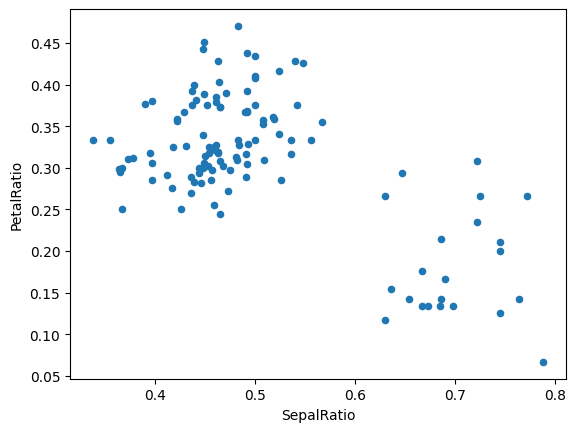

In [115]:
# Here we use method chains so we include everything in parentheses
# i.e implicit line continuation. Also, we use anonymous functions
# with one argument to be applied to the df. 
# 
# Limit the df to those observations having SepalLength greater than five, 
# calculate the ratio and finally plot. 
(
    iris
        .query("SepalLength > 5")
        .assign(SepalRatio = lambda x: x.SepalWidth / x.SepalLength, 
                PetalRatio = lambda x: x.PetalWidth / x.PetalLength) 
        .plot(kind = "scatter", x = "SepalRatio", y = "PetalRatio")
)

## Indexing / selection

In [116]:
df

,one,bar,flag,foo,one_trunc
a,1.0,1.0,False,bar,1.0
b,2.0,2.0,False,bar,2.0
c,3.0,3.0,True,bar,NaN
d,NaN,NaN,False,bar,NaN


In [119]:
# Row selection returns a Series, with index the columns of the df 
df.loc["b"]

one            2.0
bar            2.0
flag         False
foo            bar
one_trunc      2.0
Name: b, dtype: object

In [120]:
df.iloc[2] 

one           3.0
bar           3.0
flag         True
foo           bar
one_trunc     NaN
Name: c, dtype: object

## Data alignment and arithmetic

In [121]:
# The resulting object will have the UNION of both columns and row labels 
df = pd.DataFrame(np.random.randn(10, 4), columns = ["A", "B", "C", "D"]) 
df2 = pd.DataFrame(np.random.randn(7, 3), columns = ["A", "B", "C"]) 
df + df2

,A,B,C,D
0,1.150109,0.144068,-1.078536,NaN
1,-0.884091,-0.271442,0.204189,NaN
2,2.676838,-0.968886,1.892615,NaN
3,0.566948,-0.595316,2.741473,NaN
4,0.058004,-0.860683,0.871635,NaN
5,1.521115,0.883824,-1.622249,NaN
6,0.630488,1.295101,2.492430,NaN
7,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN


In [123]:
df

,A,B,C,D
0,0.894137,-0.543843,0.019655,2.377690
1,-0.745240,0.941269,-0.137199,-0.324111
2,1.756191,-0.825547,1.459282,0.063551
3,-0.109993,-0.423247,0.698547,-0.026336
4,0.676913,0.367345,1.365593,-0.328988
5,0.119453,1.065246,0.796999,1.888931
6,-0.114614,1.269008,1.730941,-0.054714
7,0.780312,-1.178041,-0.285848,-0.641808
8,-0.923275,3.001678,-0.739995,-0.060033
9,1.724034,-0.847233,-0.330147,0.453579


In [122]:
df - df.iloc[0]

,A,B,C,D
0,0.000000,0.000000,0.000000,0.000000
1,-1.639377,1.485112,-0.156855,-2.701801
2,0.862054,-0.281704,1.439627,-2.314139
3,-1.004130,0.120596,0.678891,-2.404026
4,-0.217224,0.911188,1.345938,-2.706678
5,-0.774684,1.609089,0.777344,-0.488759
6,-1.008751,1.812851,1.711285,-2.432404
7,-0.113825,-0.634198,-0.305503,-3.019498
8,-1.817412,3.545521,-0.759651,-2.437723
9,0.829897,-0.303390,-0.349803,-1.924111


In [124]:
# Arithmetic operations with scalars, as well as boolean operators, operate ELEMENT-WISE 
df * 5 + 2

,A,B,C,D
0,6.470685,-0.719214,2.098277,13.888449
1,-1.726198,6.706344,1.314004,0.379443
2,10.780956,-2.127735,9.296411,2.317757
3,1.450033,-0.116235,5.492734,1.868321
4,5.384566,3.836724,8.827964,0.355061
5,2.597264,7.326231,5.984995,11.444653
6,1.426931,8.345040,10.654703,1.726430
7,5.901559,-3.890206,0.570762,-1.209039
8,-2.616373,17.008390,-1.699977,1.699836
9,10.620168,-2.236167,0.349263,4.267893


In [125]:
1 / df

,A,B,C,D
0,1.118397,-1.838767,50.876727,0.420576
1,-1.341850,1.062396,-7.288670,-3.085359
2,0.569414,-1.211318,0.685268,15.735312
3,-9.091452,-2.362687,1.431543,-37.971034
4,1.477294,2.722238,0.732283,-3.039627
5,8.371511,0.938750,1.254707,0.529400
6,-8.724956,0.788017,0.577721,-18.276853
7,1.281539,-0.848867,-3.498367,-1.558099
8,-1.083101,0.333147,-1.351360,-16.657542
9,0.580035,-1.180312,-3.028950,2.204690


In [126]:
df ** 4

,A,B,C,D
0,0.639170,0.087477,1.492531e-07,3.196104e+01
1,0.308449,0.784973,3.543291e-04,1.103513e-02
2,9.512338,0.464480,4.534789e+00,1.631168e-05
3,0.000146,0.032090,2.381123e-01,4.810501e-07
4,0.209958,0.018209,3.477643e+00,1.171437e-02
5,0.000204,1.287657,4.034883e-01,1.273104e+01
6,0.000173,2.593328,8.976947e+00,8.961781e-06
7,0.370743,1.925937,6.676338e-03,1.696758e-01
8,0.726647,81.181375,2.998582e-01,1.298842e-05
9,8.834518,0.515243,1.188041e-02,4.232628e-02


In [127]:
df1 = pd.DataFrame({"a": [1, 0, 1], "b": [0, 1, 1]}, dtype = bool)
df2 = pd.DataFrame({"a": [0, 1, 1], "b": [1, 1, 0]}, dtype = bool)

In [128]:
df1 & df2 # binary AND

,a,b
0,False,False
1,False,True
2,True,False


In [129]:
df1 | df2 # binary OR

,a,b
0,True,True
1,True,True
2,True,True


In [130]:
df1 ^ df2 # exclusive OR

,a,b
0,True,True
1,True,False
2,False,True


In [131]:
-df1

,a,b
0,False,True
1,True,False
2,False,False


## Transposing

In [132]:
# Only show the first 5 rows 
df[:5].T 

,0,1,2,3,4
A,0.894137,-0.745240,1.756191,-0.109993,0.676913
B,-0.543843,0.941269,-0.825547,-0.423247,0.367345
C,0.019655,-0.137199,1.459282,0.698547,1.365593
D,2.377690,-0.324111,0.063551,-0.026336,-0.328988


## DataFrame interoperability with NumPy functions

In [133]:
np.exp(df)

,A,B,C,D
0,2.445225,0.580513,1.019850,10.779971
1,0.474621,2.563231,0.871797,0.723170
2,5.790341,0.437995,4.302870,1.065614
3,0.895840,0.654917,2.010828,0.974008
4,1.967794,1.443896,3.918045,0.719652
5,1.126880,2.901554,2.218872,6.612294
6,0.891710,3.557322,5.645962,0.946756
7,2.182153,0.307881,0.751377,0.526340
8,0.397216,20.119268,0.477116,0.941734
9,5.607099,0.428599,0.718818,1.573935


In [134]:
# convert the input to ndarray 
np.asarray(df)

array([[ 0.89413703, -0.54384284,  0.01965535,  2.37768989],
       [-0.74523967,  0.94126871, -0.13719924, -0.32411142],
       [ 1.75619127, -0.82554701,  1.45928217,  0.06355133],
       [-0.10999343, -0.42324697,  0.69854674, -0.02633586],
       [ 0.67691313,  0.36734488,  1.36559287, -0.32898777],
       [ 0.11945275,  1.0652463 ,  0.79699895,  1.88893059],
       [-0.11461376,  1.269008  ,  1.7309406 , -0.05471401],
       [ 0.78031189, -1.17804129, -0.28584762, -0.64180774],
       [-0.92327461,  3.00167799, -0.73999531, -0.06003287],
       [ 1.72403354, -0.84723331, -0.33014739,  0.45357857]])

In [135]:
ser = pd.Series([1, 2, 3, 4])
np.exp(ser)

0     2.718282
1     7.389056
2    20.085537
3    54.598150
dtype: float64

In [136]:
# When multiple Series are passed to a ufunc, their index labels are aligned first. 
ser1 = pd.Series([1, 2, 3], index = ["a", "b", "c"])
ser2 = pd.Series([1, 3, 5], index = ["b", "a", "c"])
print(ser1)
print(ser2)

a    1
b    2
c    3
dtype: int64
b    1
a    3
c    5
dtype: int64


In [137]:
np.remainder(ser1, ser2)

a    1
b    0
c    3
dtype: int64

## Console display

In [141]:
baseball = pd.read_csv("data/baseball.csv")

In [142]:
print(baseball)

       rownames         id  year  stint team   lg    g   ab   r    h  ...  \
0             4  ansonca01  1871      1  RC1  NaN   25  120  29   39  ...   
1            44  forceda01  1871      1  WS3  NaN   32  162  45   45  ...   
2            68  mathebo01  1871      1  FW1  NaN   19   89  15   24  ...   
3            99  startjo01  1871      1  NY2  NaN   33  161  35   58  ...   
4           102  suttoez01  1871      1  CL1  NaN   29  128  35   45  ...   
...         ...        ...   ...    ...  ...  ...  ...  ...  ..  ...  ...   
21694     89525  benitar01  2007      2  FLO   NL   34    0   0    0  ...   
21695     89526  benitar01  2007      1  SFN   NL   19    0   0    0  ...   
21696     89530  ausmubr01  2007      1  HOU   NL  117  349  38   82  ...   
21697     89533   aloumo01  2007      1  NYN   NL   87  328  51  112  ...   
21698     89534  alomasa02  2007      1  NYN   NL    8   22   1    3  ...   

        rbi   sb   cs  bb    so  ibb  hbp   sh   sf  gidp  
0      16.0  6.

In [143]:
baseball.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21699 entries, 0 to 21698
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  21699 non-null  int64  
 1   id        21699 non-null  object 
 2   year      21699 non-null  int64  
 3   stint     21699 non-null  int64  
 4   team      21699 non-null  object 
 5   lg        21634 non-null  object 
 6   g         21699 non-null  int64  
 7   ab        21699 non-null  int64  
 8   r         21699 non-null  int64  
 9   h         21699 non-null  int64  
 10  X2b       21699 non-null  int64  
 11  X3b       21699 non-null  int64  
 12  hr        21699 non-null  int64  
 13  rbi       21687 non-null  float64
 14  sb        21449 non-null  float64
 15  cs        17174 non-null  float64
 16  bb        21699 non-null  int64  
 17  so        20394 non-null  float64
 18  ibb       14171 non-null  float64
 19  hbp       21322 non-null  float64
 20  sh        20739 non-null  fl

In [144]:
print(baseball.iloc[-20:, :12].to_string())

       rownames         id  year  stint team  lg    g   ab   r    h  X2b  X3b
21679     89474  finlest01  2007      1  COL  NL   43   94   9   17    3    0
21680     89480  embreal01  2007      1  OAK  AL    4    0   0    0    0    0
21681     89481  edmonji01  2007      1  SLN  NL  117  365  39   92   15    2
21682     89482  easleda01  2007      1  NYN  NL   76  193  24   54    6    0
21683     89489  delgaca01  2007      1  NYN  NL  139  538  71  139   30    0
21684     89493  cormirh01  2007      1  CIN  NL    6    0   0    0    0    0
21685     89494  coninje01  2007      2  NYN  NL   21   41   2    8    2    0
21686     89495  coninje01  2007      1  CIN  NL   80  215  23   57   11    1
21687     89497  clemero02  2007      1  NYA  AL    2    2   0    1    0    0
21688     89498  claytro01  2007      2  BOS  AL    8    6   1    0    0    0
21689     89499  claytro01  2007      1  TOR  AL   69  189  23   48   14    0
21690     89501  cirilje01  2007      2  ARI  NL   28   40   6  

### Adjust how much to print on a single row

In [150]:
pd.set_option("display.width", 40) # NOTE: default is 80! 
pd.DataFrame(np.random.randn(3, 12))

,0,1,2,3,4,5,6,7,8,9,10,11
0,-0.212285,0.089144,1.251921,-2.152990,1.739695,-0.828311,-1.597923,0.047244,-0.335400,-0.192149,-0.620425,0.172210
1,0.509626,-0.918551,-0.434001,0.880235,1.690569,-0.668724,0.640291,0.484005,0.407929,-0.561056,1.019539,-0.978284
2,-0.617685,-1.410902,-0.427128,0.037927,-0.347560,-0.448620,-0.325577,-0.730090,-0.076081,-0.791997,1.499923,-0.971117


### Adjust max width of the individual columns

In [151]:
pd.set_option("display.max_colwidth", 30) 

datafile = {
    "filename": ["filename_01", "filename_02"], 
    "path": [
        "media/user_name/storage/folder_01/filename_01", 
        "media/user_name/storage/folder_02/filename_02"
    ]
}

pd.DataFrame(datafile)

,filename,path
0,filename_01,media/user_name/storage/fo...
1,filename_02,media/user_name/storage/fo...


In [152]:
pd.set_option("display.max_colwidth", 100) 
pd.DataFrame(datafile)

,filename,path
0,filename_01,media/user_name/storage/folder_01/filename_01
1,filename_02,media/user_name/storage/folder_02/filename_02


## DataFrame column attribute access & IPython completion

In [156]:
df = pd.DataFrame({"foo1": np.random.randn(5), "foo2": np.random.randn(5)})
df

,foo1,foo2
0,0.282615,1.189585
1,0.886583,-1.581613
2,-0.055922,0.036619
3,-0.449672,-0.300269
4,-0.297406,1.352884


In [158]:
# Access a column as an attribute e.g. df.Age
df.foo1

0    0.282615
1    0.886583
2   -0.055922
3   -0.449672
4   -0.297406
Name: foo1, dtype: float64